## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Introducción al Aprendizaje Automático
**Actividad 1.** Aprendizaje de Reglas

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

El objetivo de esta actividad es diseñar un algoritmo basado en reglas, para clasificar viviendas según su ubicación San Francisco (SF) o Nueva York (NY).

In [1]:
# 1. Carga de datos
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('datos1.csv')
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [2]:
# 2. Exploración de datos y diagrama de dispersión
df.describe()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
count,492.000000,492.000000,492.000000,4.920000e+02,492.000000,492.000000,492.000000,492.000000
mean,0.544715,2.155488,1.905691,2.020696e+06,1959.103659,1522.989837,1195.632114,39.845528
std,0.498503,1.305133,1.068150,2.824055e+06,40.579602,1014.366252,733.765622,44.673248
min,0.000000,0.000000,1.000000,1.875180e+05,1880.000000,310.000000,270.000000,0.000000
25%,0.000000,1.000000,1.000000,7.490000e+05,1924.000000,832.750000,730.500000,10.000000
50%,1.000000,2.000000,2.000000,1.145000e+06,1960.000000,1312.000000,960.000000,18.500000
75%,1.000000,3.000000,2.000000,1.908750e+06,2001.000000,1809.000000,1419.000000,61.000000
max,1.000000,10.000000,10.000000,2.750000e+07,2016.000000,7800.000000,4601.000000,238.000000


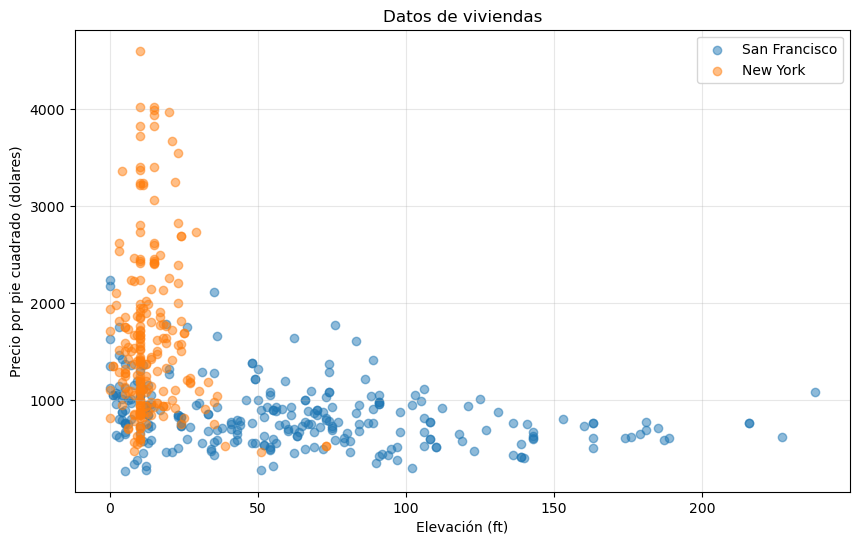

Variables (Promedios):
       elevation  price_per_sqft         sqft
in_sf                                        
0      13.504464     1626.522321  1398.044643
1      61.861940      835.485075  1627.421642


In [3]:
plt.figure(figsize=(10, 6))
viviendas_sf = df[df['in_sf'] == 1]
viviendas_ny = df[df['in_sf'] == 0]

plt.scatter(viviendas_sf['elevation'], viviendas_sf['price_per_sqft'], label='San Francisco', alpha=0.5)
plt.scatter(viviendas_ny['elevation'], viviendas_ny['price_per_sqft'], label='New York', alpha=0.5)

plt.xlabel('Elevación (ft)')
plt.ylabel('Precio por pie cuadrado (dolares)')
plt.title('Datos de viviendas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Variables (Promedios):")
print(df.groupby('in_sf')[['elevation', 'price_per_sqft', 'sqft']].mean())

In [4]:
# 3. Reglas
def clasificacion_reglas(fila, limite_elevacion, limite_precio_ny, anio_constr_sf):
  # Regla 1. Si la elevación es alta, esta en San Francisco.
  if fila['elevation'] > limite_elevacion:
      return 1
  # Regla 2. Si es una zona baja pero tiene un costo alto, es Nueva York.
  if fila['price_per_sqft'] > limite_precio_ny:
      return 0
  # Regla 3. Si es una vivienda con año de construcción antiguo, es San Francisco.
  if fila['year_built'] < anio_constr_sf:
      return 1

  # No clasificado si no cumple con alguna de las reglas anteriores.
  return -1

#
# Iteraciones con experimentos para ajuste del algoritmo
# (elevación, precio, año construido)
#
iteraciones = [
  (10, 500, 1900),
  (15, 600, 1910),
  (20, 700, 1920),
  (30, 800, 1930),
  (45, 1000, 1940),
  (55, 1200, 1950),
  (50, 1300, 1945),
  (45, 1250, 1940),
  (42, 1200, 1938),
  (40, 1250, 1935)
]

In [5]:
# 4. Algoritmo iterativo y validación de datos
lista_precision = []
print(f"{'Iteración':<10} | {'Elevación':<10} | {'Precio':<8} | {'Exactitud (%)':<15}")
print("-" * 60)

for i, params in enumerate(iteraciones):
  u_elev, p_lim, a_corte = params
  correctos = 0
  no_clasificados = 0
  total_datos = len(df)

  for _, fila in df.iterrows():
    prediccion = clasificacion_reglas(fila, u_elev, p_lim, a_corte)
    if prediccion == -1:
      no_clasificados += 1
    elif prediccion == fila['in_sf']:
      correctos += 1
    
  exactitud = (correctos / total_datos) * 100
  lista_precision.append(exactitud)
  print(f"{i+1:<10} | {u_elev:<10} | {p_lim:<8} | {exactitud:<15.2f}")

Iteración  | Elevación  | Precio   | Exactitud (%)  
------------------------------------------------------------
1          | 10         | 500      | 69.92          
2          | 15         | 600      | 73.98          
3          | 20         | 700      | 77.24          
4          | 30         | 800      | 79.47          
5          | 45         | 1000     | 69.92          
6          | 55         | 1200     | 64.63          
7          | 50         | 1300     | 63.21          
8          | 45         | 1250     | 64.02          
9          | 42         | 1200     | 65.65          
10         | 40         | 1250     | 64.63          


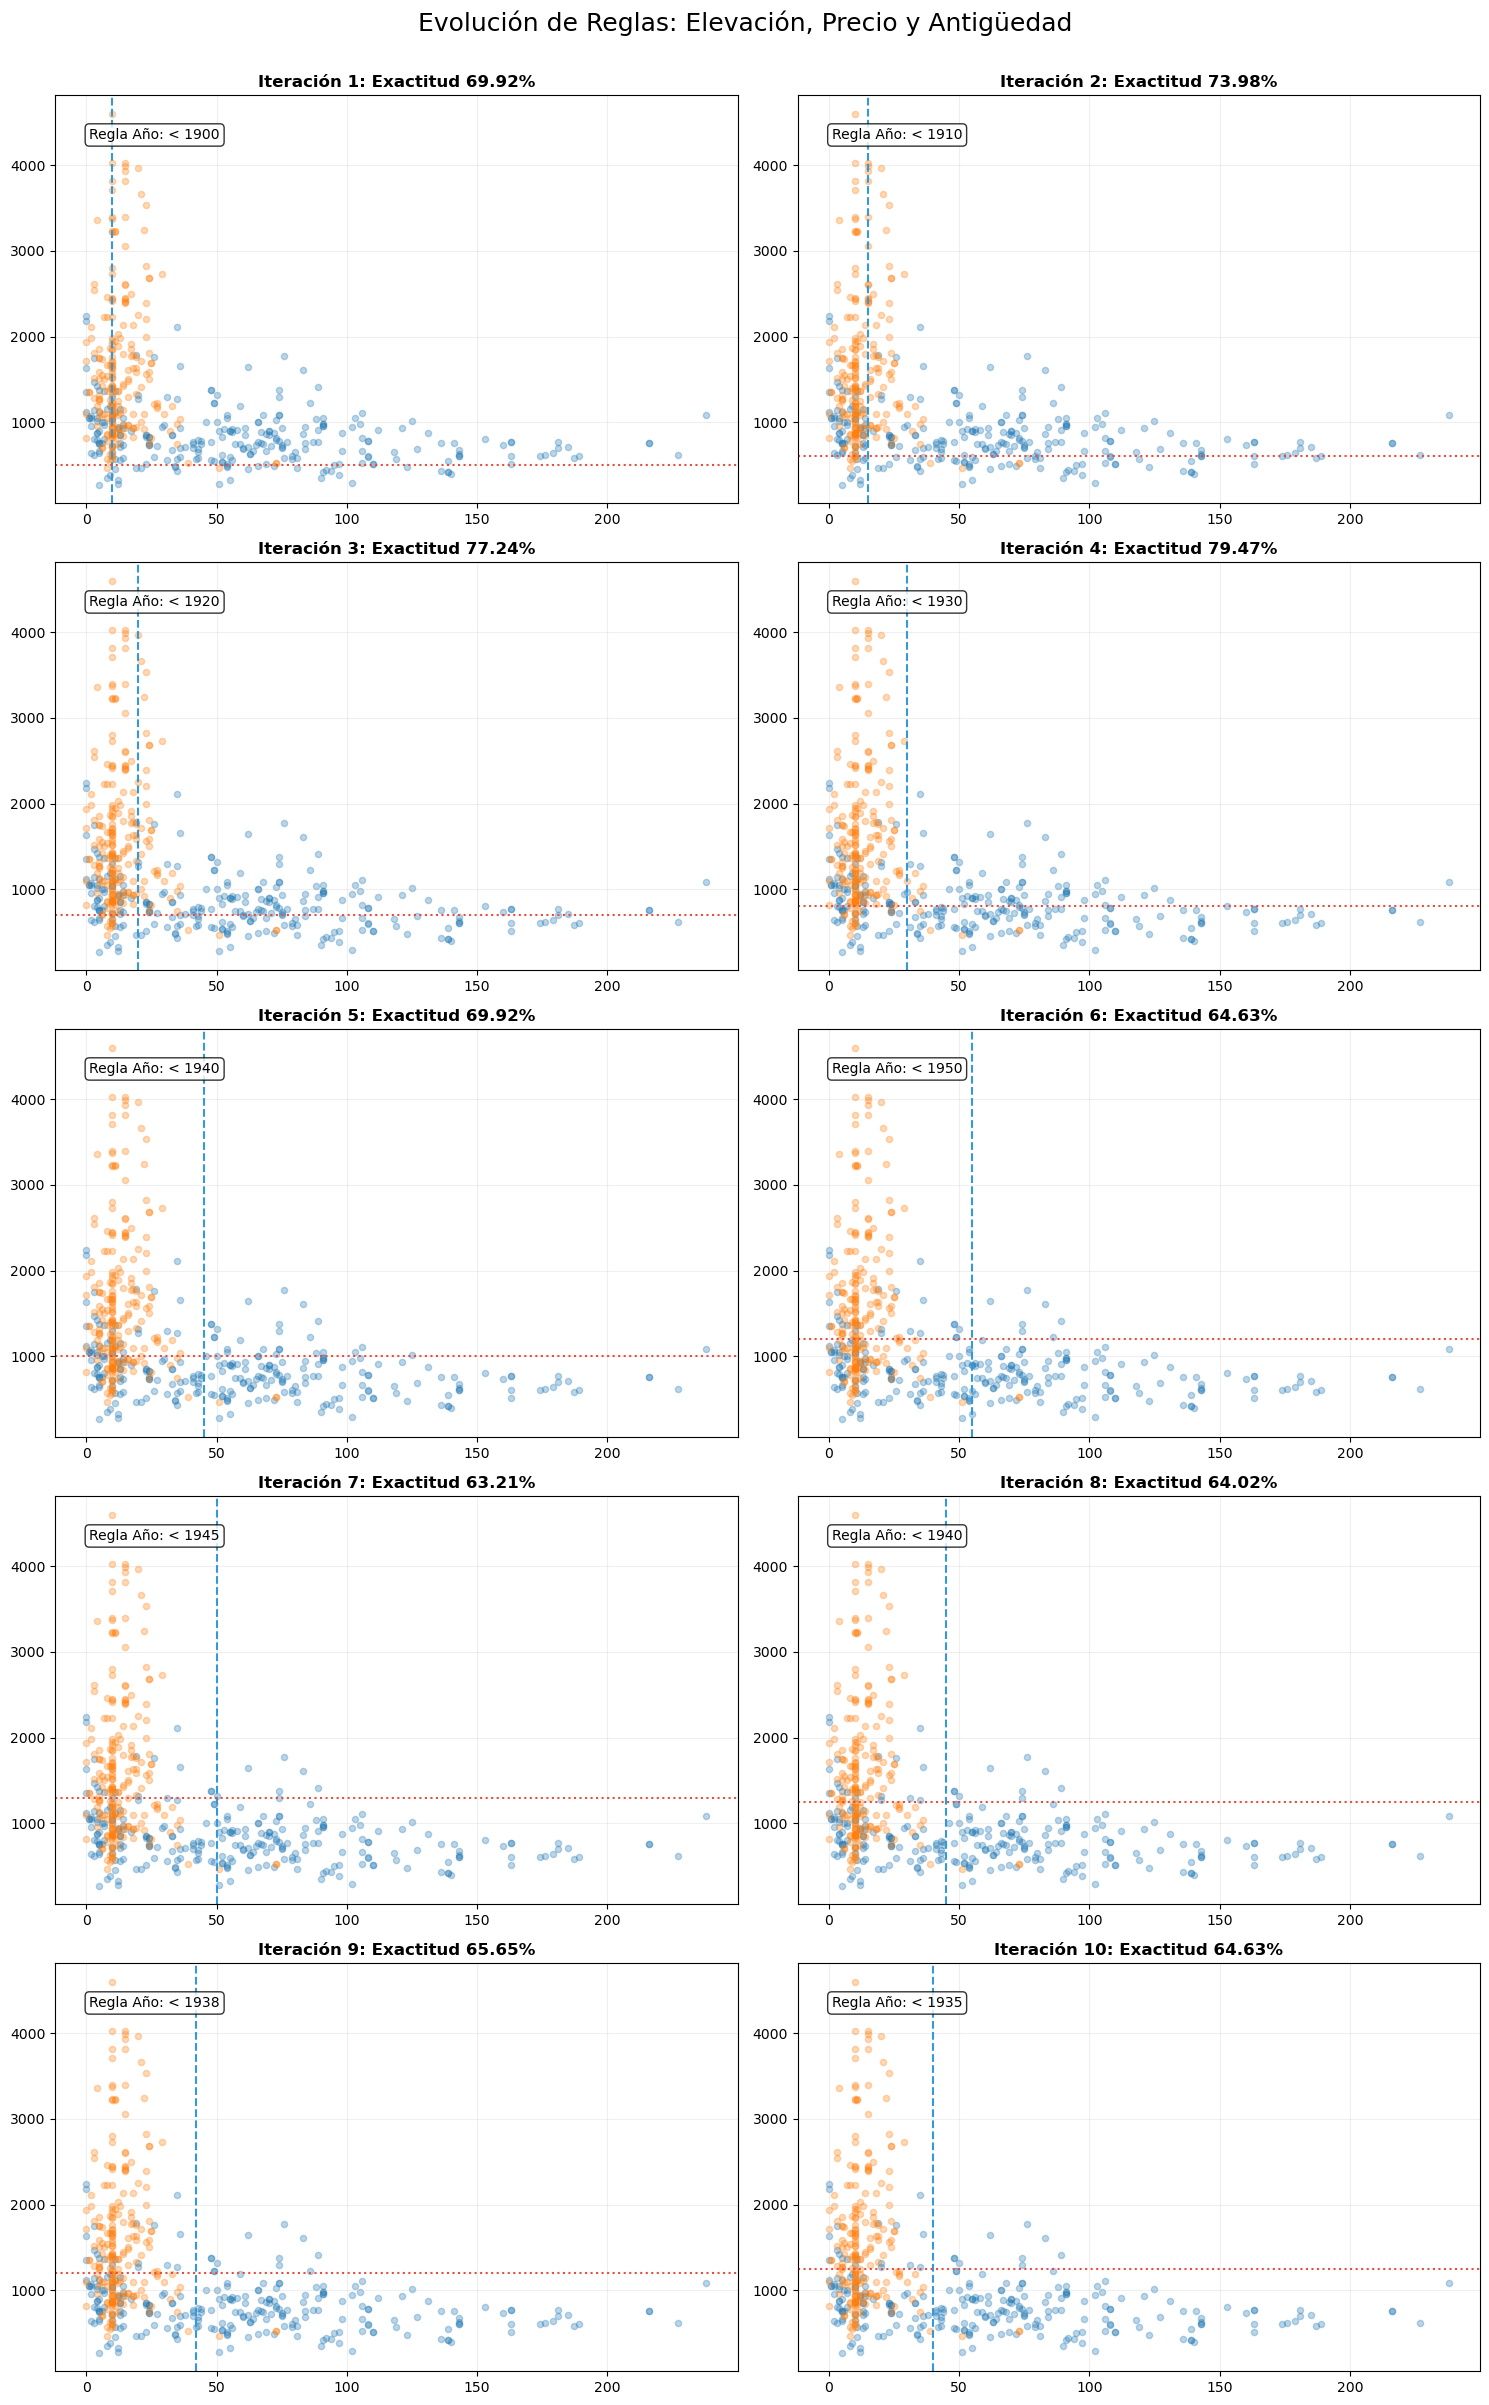

In [6]:
# 5. Visualización del algoritmo
fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()

for i in range(len(iteraciones)):
  ax = axes[i]
  u_elev, u_prec, u_anio = iteraciones[i]
  ax.scatter(viviendas_sf['elevation'], viviendas_sf['price_per_sqft'], alpha=0.3, s=20, label='SF')
  ax.scatter(viviendas_ny['elevation'], viviendas_ny['price_per_sqft'], alpha=0.3, s=20, label='NY')
  
  ax.axvline(x=u_elev, color='#3498db', linestyle='--', linewidth=1.5) # Elevación
  ax.axhline(y=u_prec, color='#e74c3c', linestyle=':', linewidth=1.5) # Precio
  
  # Antigüedad
  ax.text(0.05, 0.92, f'Regla Año: < {u_anio}', transform=ax.transAxes, 
    fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
  ax.set_title(f"Iteración {i + 1}: Exactitud {lista_precision[i]:.2f}%", fontweight='bold')
  ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle("Evolución de Reglas: Elevación, Precio y Antigüedad", fontsize=18, y=0.99)
plt.show()